# EDA de producción de biocombustibles

**Proyecto BCR · Lab 2 · Épica E3 (SCRUM-19)**

Análisis exploratorio del target: producción mensual de biodiesel (tn) y de
bioetanol total, de maíz y de caña (m³). Para cada serie se mira nivel,
índice base 2013, transformación logarítmica y variación mensual,
estacionalidad (STL), autocorrelación (ACF/PACF), estacionariedad (ADF) y
outliers.

Las series y su ventana de entrenamiento propuesta (primer mes con datos
representativos) son:

| Serie | Unidad | Inicio entrenamiento | Esquema |
|---|---|---|---|
| biodiesel | toneladas | 2008-01 | multiplicativo (log) |
| bioetanol total | m³ | 2013-01 | aditivo |
| bioetanol maíz | m³ | 2012-09 | aditivo |
| bioetanol caña | m³ | 2013-01 | aditivo |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (12, 4)

bd = pd.read_csv("../data/produccion_biodiesel.csv", parse_dates=["fecha"]).set_index("fecha")
be = pd.read_csv("../data/produccion_bioetanol.csv", parse_dates=["fecha"]).set_index("fecha")

# (serie, unidad, inicio de entrenamiento)
SERIES = {
    "biodiesel":       (bd["produccion_tn"],        "toneladas", "2008-01"),
    "bioetanol_total": (be["produccion_total_m3"],  "m³",        "2013-01"),
    "bioetanol_maiz":  (be["produccion_maiz_m3"],   "m³",        "2012-09"),
    "bioetanol_cana":  (be["produccion_cana_m3"],   "m³",        "2013-01"),
}
# mes de quiebre de nivel a marcar en los gráficos (a validar con BCR)
CORTE = pd.Timestamp("2025-11-01")

for nom, (s, u, ini) in SERIES.items():
    s = s[s > 0]
    print(f"{nom:16s}: {s.index.min().date()} → {s.index.max().date()}  ({len(s)} meses, {u})")

biodiesel       : 2008-01-01 → 2026-08-01  (224 meses, toneladas)
bioetanol_total : 2009-11-01 → 2026-08-01  (202 meses, m³)
bioetanol_maiz  : 2012-09-01 → 2026-08-01  (168 meses, m³)
bioetanol_cana  : 2009-11-01 → 2026-08-01  (202 meses, m³)


## 1. Producción cruda, con outliers y corte de nivel marcados

Se grafica cada serie en nivel. Se marcan en rojo los **outliers** (residuo
STL mayor a 3 desvíos) y con línea punteada el **corte de nivel de
noviembre 2025** que hay que validar con BCR.

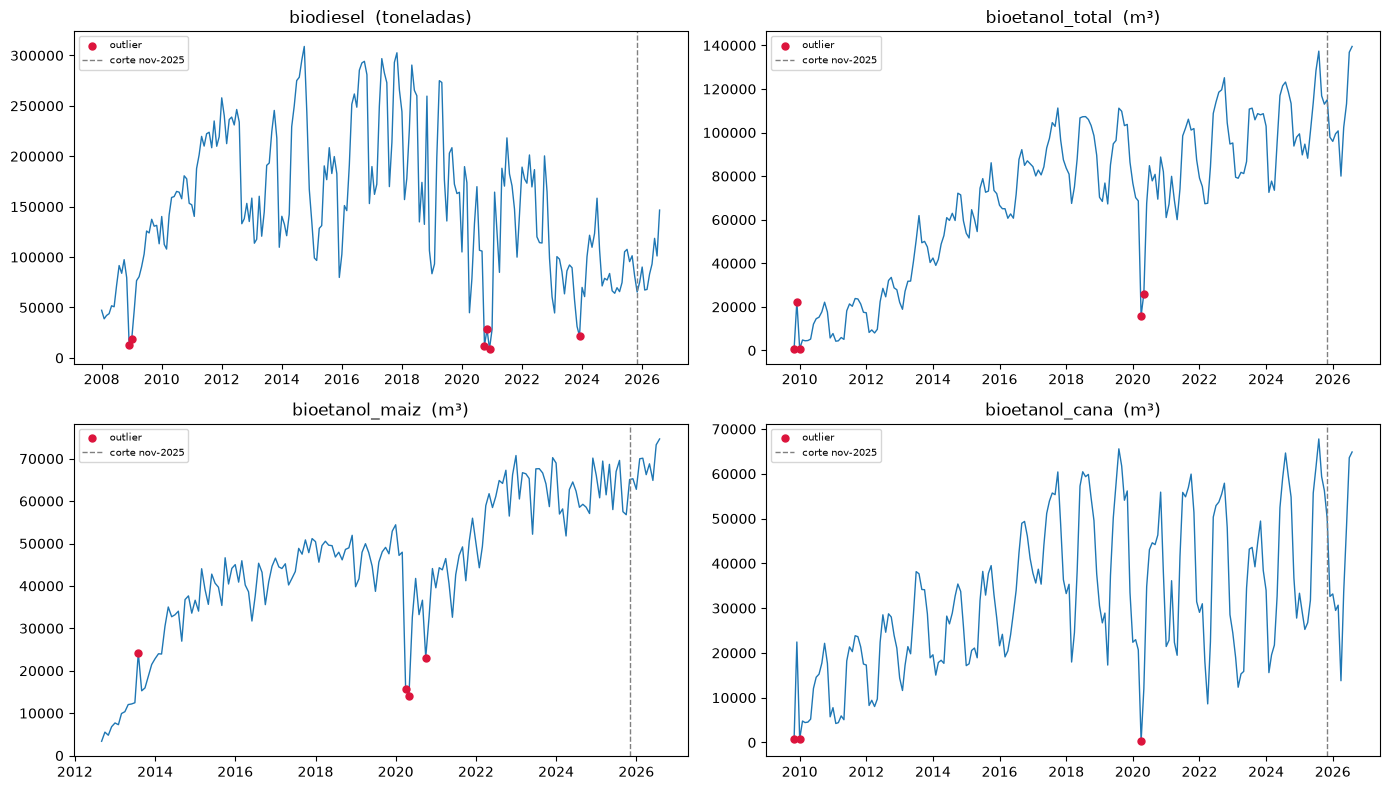

biodiesel       : outliers → ['2008-12', '2009-01', '2020-10', '2020-11', '2020-12', '2023-12']
bioetanol_total : outliers → ['2009-11', '2009-12', '2010-01', '2020-04', '2020-05']
bioetanol_maiz  : outliers → ['2013-08', '2020-04', '2020-05', '2020-10']
bioetanol_cana  : outliers → ['2009-11', '2010-01', '2020-04']


In [2]:
def outliers_stl(s, k=3.0):
    """Devuelve las fechas con residuo STL (en log) mayor a k desvíos."""
    s = s[s > 0].asfreq("MS")
    res = STL(np.log(s), period=12, robust=True).fit().resid
    z = (res - res.mean()) / res.std()
    return s.index[np.abs(z) > k]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (nom, (s, u, ini)) in zip(axes.ravel(), SERIES.items()):
    s = s[s > 0]
    ax.plot(s.index, s.values, lw=1)
    out = outliers_stl(s)
    ax.scatter(out, s.loc[out], color="crimson", zorder=5, s=25, label="outlier")
    ax.axvline(CORTE, color="gray", ls="--", lw=1, label="corte nov-2025")
    ax.set_title(f"{nom}  ({u})"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

for nom, (s, u, ini) in SERIES.items():
    out = outliers_stl(s[s > 0])
    print(f"{nom:16s}: outliers →", [d.strftime('%Y-%m') for d in out])

Los outliers caen sobre todo en **2020-2021** (shock de pandemia, con caídas
y rebotes fuertes) y en el arranque de cada serie. Son los puntos que después
el regARIMA del X-13 corrige antes de modelar.

## 2. Índice base 2013 = 100

Es la representación que usa BCR para el IACA: cada serie se expresa como
índice con promedio 2013 = 100. Permite comparar las cuatro en la misma
escala relativa.

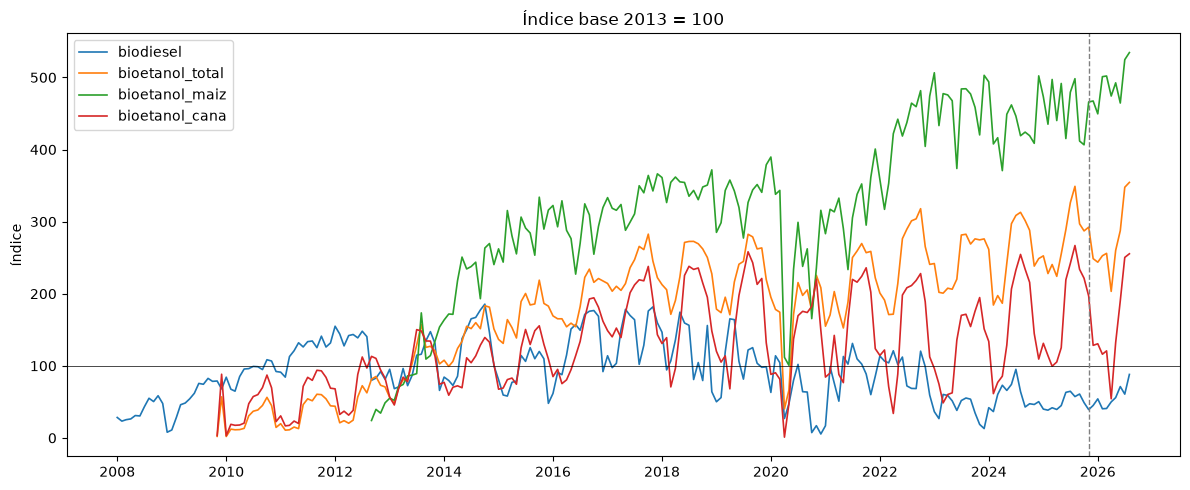

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for nom, (s, u, ini) in SERIES.items():
    s = s[s > 0]
    base = s[s.index.year == 2013].mean()
    idx = s / base * 100
    ax.plot(idx.index, idx.values, lw=1.2, label=nom)
ax.axhline(100, color="k", lw=0.5)
ax.axvline(CORTE, color="gray", ls="--", lw=1)
ax.set_title("Índice base 2013 = 100"); ax.set_ylabel("índice"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Transformación logarítmica y variación mensual

Para las cuatro series: el log estabiliza la varianza (crece con el nivel), y
la variación mensual en log (`Δ log`) es aproximadamente el cambio porcentual
mes a mes. Se grafican las dos por serie.

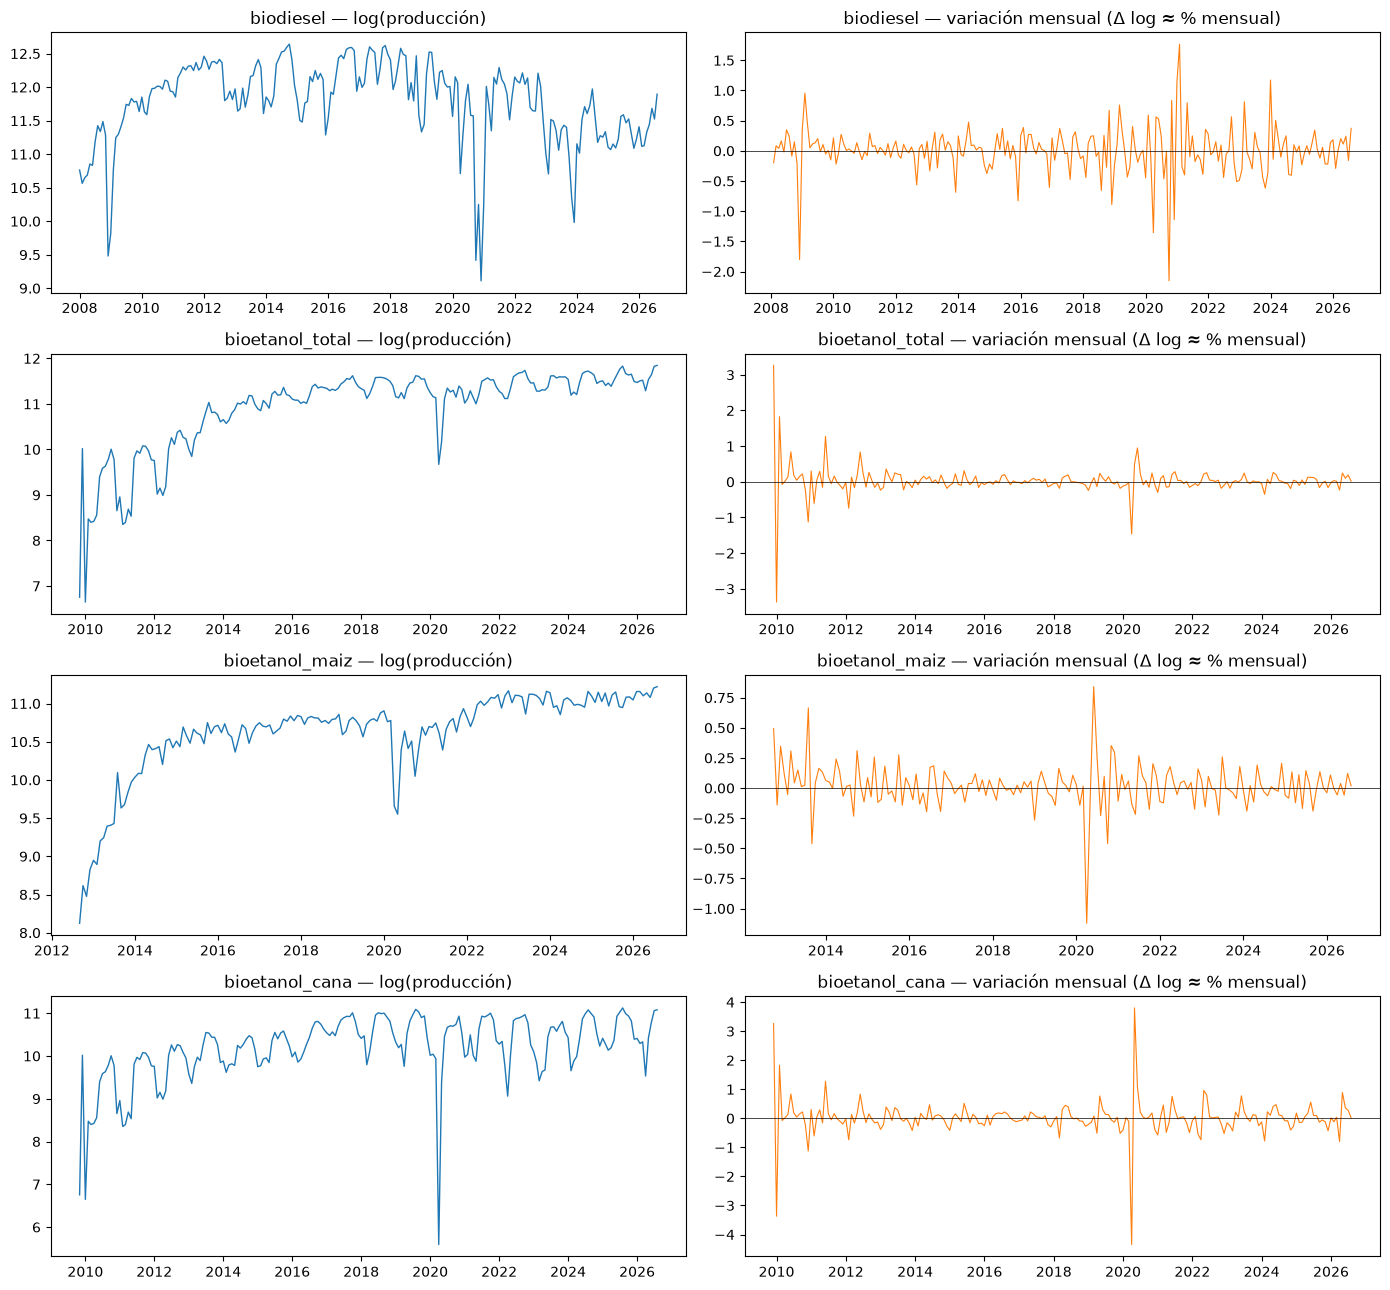

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 13))
for fila, (nom, (s, u, ini)) in zip(axes, SERIES.items()):
    s = s[s > 0]
    logs = np.log(s)
    dlog = logs.diff()
    fila[0].plot(logs.index, logs.values, lw=1)
    fila[0].set_title(f"{nom} — log(producción)")
    fila[1].plot(dlog.index, dlog.values, lw=0.8, color="tab:orange")
    fila[1].axhline(0, color="k", lw=0.5)
    fila[1].set_title(f"{nom} — variación mensual (Δ log ≈ % mensual)")
plt.tight_layout(); plt.show()

## 4. Estacionalidad (STL) y perfil mensual

Se descompone cada serie con STL (en log) y se mide la **fuerza estacional**
= 1 − var(resto) / var(estacional + resto). Para biodiesel se reporta además
la fuerza **excluyendo 2020-2021**, porque el shock de pandemia infla el
residuo y esconde la estacionalidad real.

In [5]:
def fuerza_estacional(s):
    s = s[s > 0].asfreq("MS")
    r = STL(np.log(s), period=12, robust=True).fit()
    return max(0.0, 1 - r.resid.var() / (r.seasonal + r.resid).var())

print("Fuerza estacional (0 = nula, 1 = total):")
for nom, (s, u, ini) in SERIES.items():
    s = s[s > 0]
    f = fuerza_estacional(s)
    extra = ""
    if nom == "biodiesel":
        f19 = fuerza_estacional(s[(s.index.year >= 2013) & (s.index.year <= 2019)])
        extra = f"   | 2013-2019 (sin shock): {f19:.3f}"
    print(f"  {nom:16s}: {f:.3f}{extra}")

Fuerza estacional (0 = nula, 1 = total):
  biodiesel       : 0.224   | 2013-2019 (sin shock): 0.681
  bioetanol_total : 0.338
  bioetanol_maiz  : 0.078
  bioetanol_cana  : 0.522


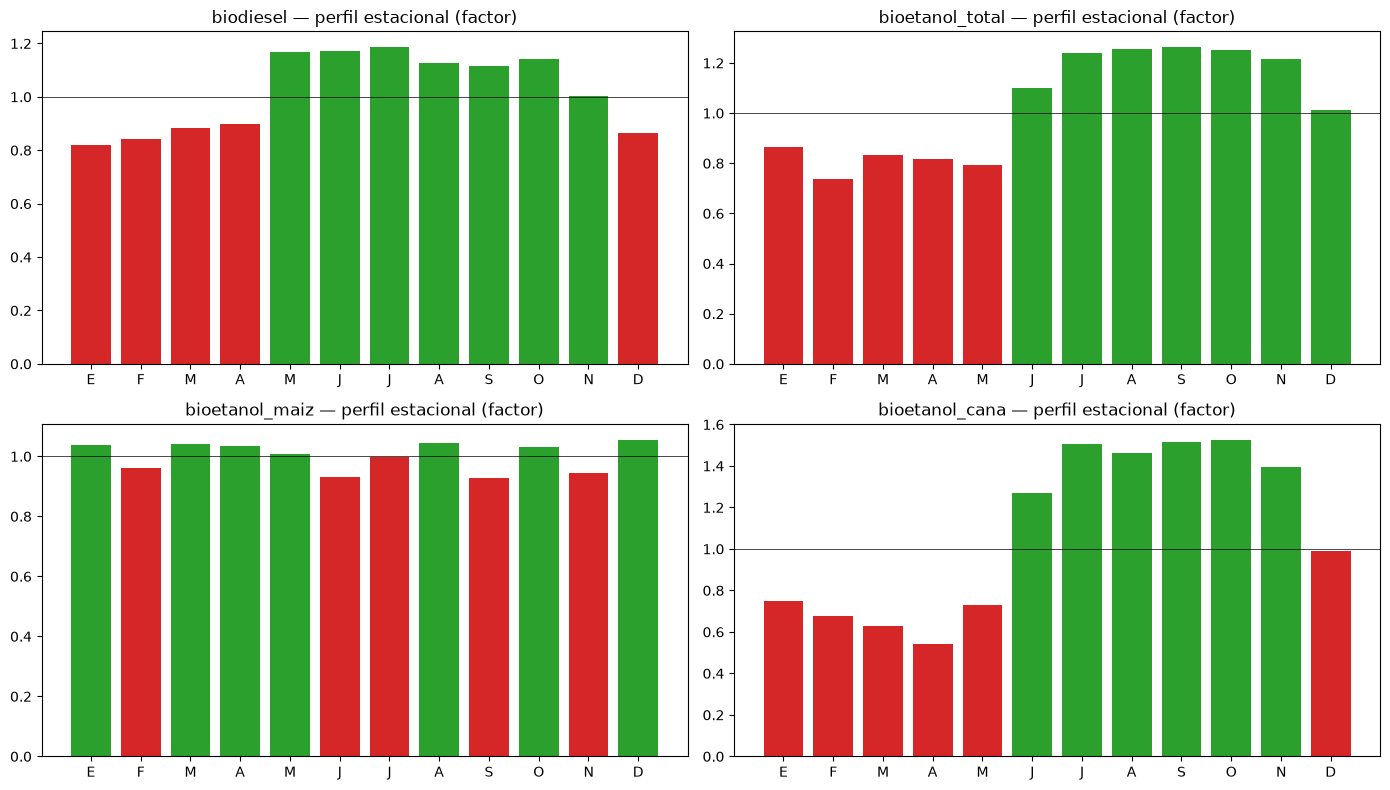

In [6]:
# perfil estacional promedio por mes (factor multiplicativo) de cada serie
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
meses = ["E","F","M","A","M","J","J","A","S","O","N","D"]
for ax, (nom, (s, u, ini)) in zip(axes.ravel(), SERIES.items()):
    s = s[s > 0].asfreq("MS")
    comp = STL(np.log(s), period=12, robust=True).fit()
    fac = np.exp(comp.seasonal).groupby(comp.seasonal.index.month).mean()
    ax.bar(range(1, 13), fac.values, color=["tab:green" if v >= 1 else "tab:red" for v in fac.values])
    ax.axhline(1, color="k", lw=0.5)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses)
    ax.set_title(f"{nom} — perfil estacional (factor)")
plt.tight_layout(); plt.show()

**Lectura por serie:**

- **Biodiesel — estacionalidad FUERTE** (corrección respecto de versiones
  previas que la daban como "leve/opcional"). La fuerza STL global sale baja
  (~0.22) **solo por el shock 2020-2021**; en 2013-2019 da **~0.68**. Y la
  descomposición real del X-13 de BCR muestra factores que van de **0.79
  (febrero) a 1.26 (julio)**: pisos y techos del 20-25 %. No es opcional:
  hay que modelarla.
- **Bioetanol caña — estacionalidad fuerte** (STL ~0.52): zafra azucarera,
  patrón marcado.
- **Bioetanol total — moderada** (STL ~0.34).
- **Bioetanol maíz — leve** (STL ~0.08): producción casi plana todo el año.

## 5. Autocorrelación (ACF / PACF)

Para cada serie, sobre la variación mensual (`Δ log`) y su ventana de
entrenamiento. Ayuda a proponer órdenes AR/MA para los modelos.

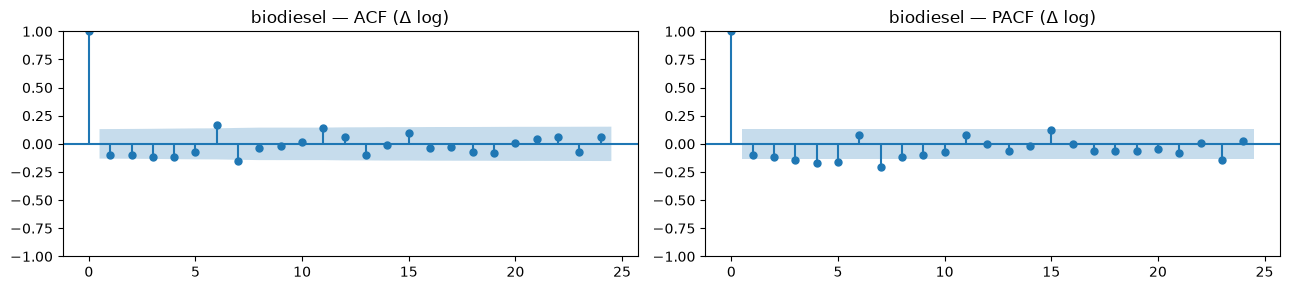

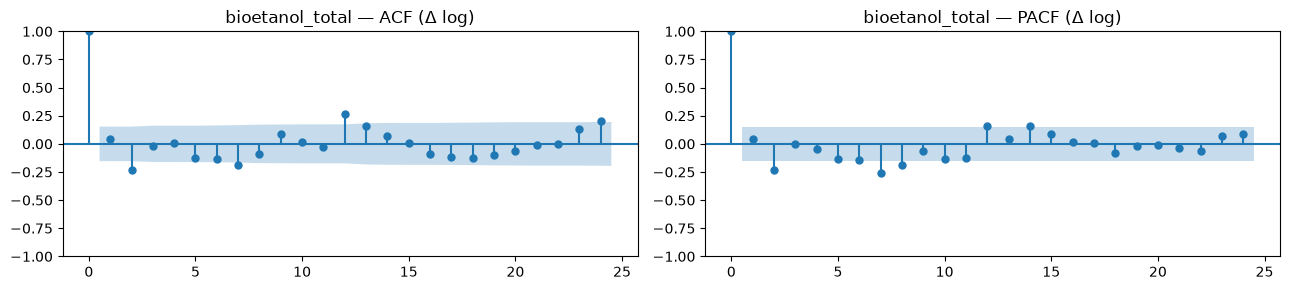

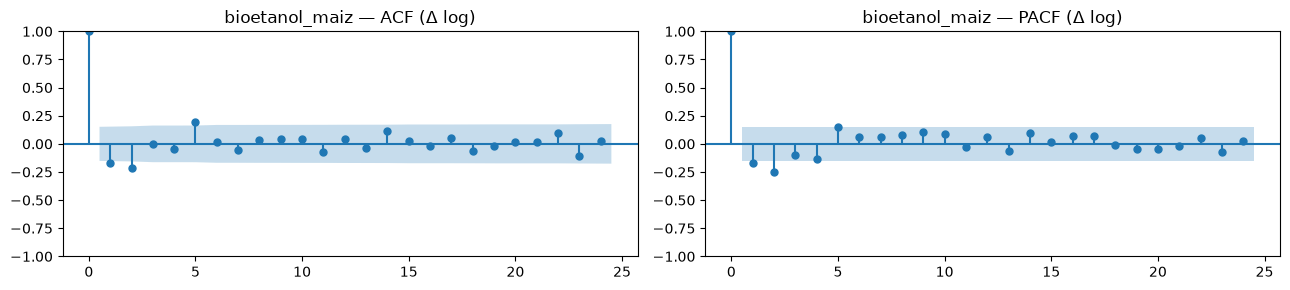

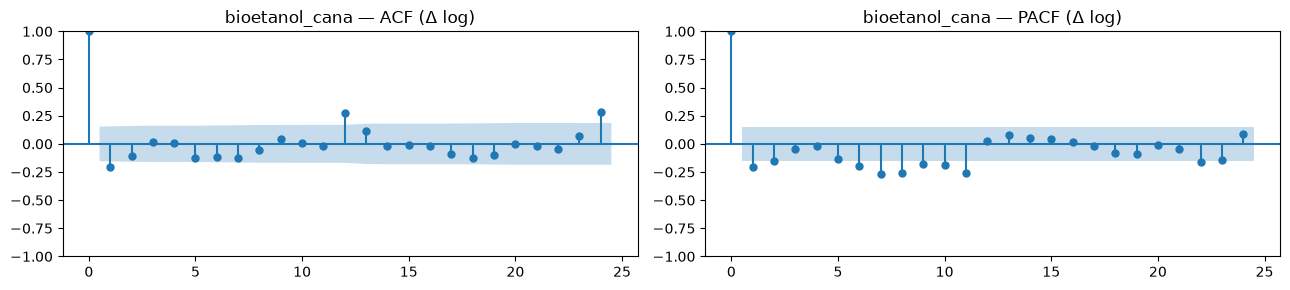

In [7]:
for nom, (s, u, ini) in SERIES.items():
    s = s[s > 0]
    dlog = np.log(s[s.index >= ini]).diff().dropna()
    fig, ax = plt.subplots(1, 2, figsize=(13, 3))
    plot_acf(dlog, lags=24, ax=ax[0]); ax[0].set_title(f"{nom} — ACF (Δ log)")
    plot_pacf(dlog, lags=24, ax=ax[1], method="ywm"); ax[1].set_title(f"{nom} — PACF (Δ log)")
    plt.tight_layout(); plt.show()

## 6. Estacionariedad (ADF) sobre la ventana de entrenamiento

El test ADF se corre **sobre la ventana que cada serie va a usar**, no sobre
toda la historia. Esto importa: en bioetanol total, el arranque 2009-2012
(producción casi nula) distorsiona el test; desde 2013 el panorama cambia.

In [8]:
def adf_p(s, log=True):
    x = np.log(s) if log else s
    return adfuller(x.dropna())[1]

print("ADF p-valor (menor a 0.05 ≈ estacionario):\n")
for nom, (s, u, ini) in SERIES.items():
    s = s[s > 0]
    p_todo = adf_p(s)
    p_vent = adf_p(s[s.index >= ini])
    p_dif = adf_p(np.log(s[s.index >= ini]).diff().dropna(), log=False)
    print(f"  {nom:16s}: toda la serie={p_todo:.3f} | desde {ini}={p_vent:.3f} | "
          f"Δlog desde {ini}={p_dif:.3f}")

ADF p-valor (menor a 0.05 ≈ estacionario):

  biodiesel       : toda la serie=0.039 | desde 2008-01=0.039 | Δlog desde 2008-01=0.000
  bioetanol_total : toda la serie=0.000 | desde 2013-01=0.040 | Δlog desde 2013-01=0.000
  bioetanol_maiz  : toda la serie=0.000 | desde 2012-09=0.000 | Δlog desde 2012-09=0.000
  bioetanol_cana  : toda la serie=0.063 | desde 2013-01=0.262 | Δlog desde 2013-01=0.000


**Lectura:** en **nivel**, las series no son estacionarias (bioetanol total,
por ejemplo, da p≈0.43-0.51: tiene tendencia). Al tomar la **variación
mensual (`Δ log`)** todas se vuelven claramente estacionarias (p≈0.000). Eso
respalda usar diferenciación `d=1` en los modelos tipo ARIMA.

Sobre el punto que levantó el review: el resultado del ADF es sensible a la
ventana, a la transformación (nivel vs log) y a la config del test (lags,
término determinístico). Por eso lo corremos **sobre la ventana de
entrenamiento de cada serie y reportando nivel, ventana y `Δ log`** por
separado, en vez de un único número global que puede engañar según cómo se
calcule. La conclusión robusta —que no depende de esos detalles— es que en
nivel hay tendencia y que al diferenciar se estabiliza.

## 7. Crecimiento de largo plazo (corregido)

Nota metodológica: el crecimiento del bioetanol **no es "×160"**. Esa cifra
comparaba contra el mes de arranque (nov-2009, 858 m³), que es un piso
artificial. Año contra año, el promedio mensual de **2025 es ~10× el de
2010** — un crecimiento igualmente enorme, pero medido bien.

In [9]:
bt = be["produccion_total_m3"]; bt = bt[bt > 0]
m2010 = bt[bt.index.year == 2010].mean()
m2025 = bt[bt.index.year == 2025].mean()
print(f"Bioetanol total — media mensual 2010: {m2010:,.0f} m³")
print(f"Bioetanol total — media mensual 2025: {m2025:,.0f} m³")
print(f"Crecimiento 2010 → 2025: ×{m2025/m2010:.1f}")
print(f"(el mes de arranque nov-2009 fue {bt.iloc[0]:,.0f} m³: comparar contra eso da el engañoso ×{m2025/bt.iloc[0]:.0f})")

Bioetanol total — media mensual 2010: 10,411 m³
Bioetanol total — media mensual 2025: 107,907 m³
Crecimiento 2010 → 2025: ×10.4
(el mes de arranque nov-2009 fue 858 m³: comparar contra eso da el engañoso ×126)


## 8. Conclusiones y propuesta por serie

| Serie | Estacionalidad | Estacionariedad | Transformación | Nota |
|---|---|---|---|---|
| **biodiesel** | **fuerte** (0.68 sin shock; X-13 0.79–1.26) | Δlog estacionaria | log | outliers 2020-21 |
| **bioetanol total** | moderada (~0.34) | Δlog estacionaria desde 2013 | log/nivel | arranque 2009-12 distorsiona |
| **bioetanol maíz** | leve (~0.08) | Δlog estacionaria | log/nivel | casi plana |
| **bioetanol caña** | fuerte (~0.52, zafra) | con tendencia | log/nivel | patrón de zafra marcado |

**Para el modelado:**
1. Todas requieren diferenciación (`d=1`) o equivalente; en nivel no son
   estacionarias.
2. Estacionalidad a modelar sí o sí en **biodiesel** y **caña**; moderada en
   total; casi nula en maíz.
3. Tratar los **outliers 2020-2021** (el X-13 ya los corrige vía regARIMA;
   en los modelos propios habrá que decidir cómo).
4. Correr siempre los tests y entrenar **desde la ventana propia de cada
   serie**, no desde el arranque con ceros.
5. Validar con BCR el **corte de nivel de nov-2025** antes de tratarlo como
   quiebre estructural.